<a href="https://colab.research.google.com/github/addujayathi/OIBSIP/blob/Project2/Houseprice_LinearReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libs

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
#loading and understanding the data

In [ ]:
df= pd.read_csv('/content/Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.duplicated().sum()

np.int64(0)

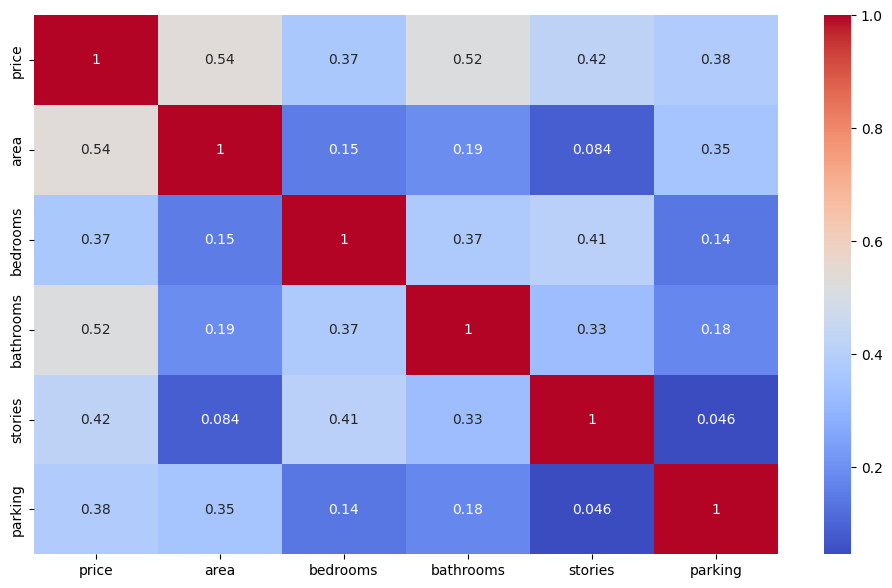

In [ ]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.show()

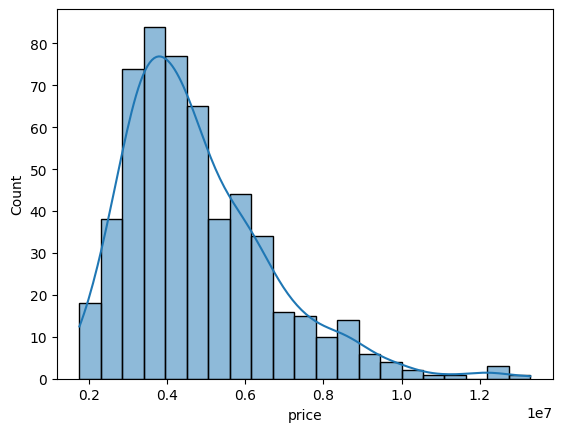

In [ ]:
sns.histplot(df['price'],kde=True)
plt.show()

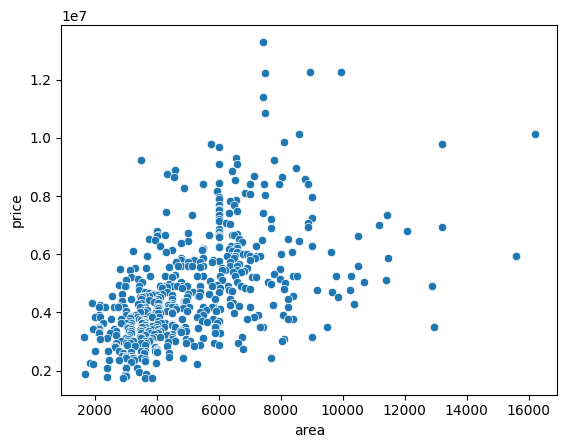

In [ ]:
sns.scatterplot(x='area',y='price',data=df)
plt.show()

In [ ]:
#data preprocessing

In [ ]:
df['furnishingstatus'].fillna('Unknown', inplace=True)
df

/tmp/ipykernel_5210/1051570361.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['furnishingstatus'].fillna('Unknown', inplace=True)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df['furnishingstatus'] = df['furnishingstatus'].fillna('Unknown')
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
1,12250000,8960,4,4,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
2,12250000,9960,3,2,2,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
3,12215000,7500,4,2,2,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
4,11410000,7420,4,1,2,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
541,1767150,2400,3,1,1,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
542,1750000,3620,2,1,1,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
543,1750000,2910,3,1,1,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,NaN,NaN
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,NaN,NaN
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,NaN,NaN
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,NaN,NaN
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,NaN,NaN
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,NaN,NaN
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,NaN,NaN
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            545 non-null    int64  
 1   area                             545 non-null    int64  
 2   bedrooms                         545 non-null    int64  
 3   bathrooms                        545 non-null    int64  
 4   stories                          545 non-null    int64  
 5   mainroad                         0 non-null      float64
 6   guestroom                        0 non-null      float64
 7   basement                         0 non-null      float64
 8   hotwaterheating                  0 non-null      float64
 9   airconditioning                  0 non-null      float64
 10  parking                          545 non-null    int64  
 11  prefarea                         0 non-null      float64
 12  furnishingstatus_semi-

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df[scaled_columns] = scaler.fit_transform(df[scaled_columns])
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.046726,1.403419,1.421812,1.378217,NaN,NaN,NaN,NaN,NaN,1.517692,NaN,NaN,NaN
1,12250000,1.757010,1.403419,5.405809,2.532024,NaN,NaN,NaN,NaN,NaN,2.679409,NaN,NaN,NaN
2,12250000,2.218232,0.047278,1.421812,0.224410,NaN,NaN,NaN,NaN,NaN,1.517692,NaN,NaN,NaN
3,12215000,1.083624,1.403419,1.421812,0.224410,NaN,NaN,NaN,NaN,NaN,2.679409,NaN,NaN,NaN
4,11410000,1.046726,1.403419,-0.570187,0.224410,NaN,NaN,NaN,NaN,NaN,1.517692,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,-1.308863,-0.570187,-0.929397,NaN,NaN,NaN,NaN,NaN,1.517692,NaN,NaN,NaN
541,1767150,-1.268613,0.047278,-0.570187,-0.929397,NaN,NaN,NaN,NaN,NaN,-0.805741,NaN,NaN,NaN
542,1750000,-0.705921,-1.308863,-0.570187,-0.929397,NaN,NaN,NaN,NaN,NaN,-0.805741,NaN,NaN,NaN
543,1750000,-1.033389,0.047278,-0.570187,-0.929397,NaN,NaN,NaN,NaN,NaN,-0.805741,NaN,NaN,NaN


In [ ]:
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning',
               'prefarea']

# Convert 'yes'/'no' to 1/0
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Convert 'furnishingstatus' to dummy variables
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

X = df.drop('price', axis=1)

In [ ]:
y = df['price']
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [ ]:
print(X.head())
print(y.head())

       area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
0  1.046726  1.403419   1.421812  1.378217       NaN        NaN       NaN   
1  1.757010  1.403419   5.405809  2.532024       NaN        NaN       NaN   
2  2.218232  0.047278   1.421812  0.224410       NaN        NaN       NaN   
3  1.083624  1.403419   1.421812  0.224410       NaN        NaN       NaN   
4  1.046726  1.403419  -0.570187  0.224410       NaN        NaN       NaN   

   hotwaterheating  airconditioning   parking  prefarea  \
0              NaN              NaN  1.517692       NaN   
1              NaN              NaN  2.679409       NaN   
2              NaN              NaN  1.517692       NaN   
3              NaN              NaN  2.679409       NaN   
4              NaN              NaN  1.517692       NaN   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                              NaN                           NaN  
1                              NaN              

In [ ]:
#train test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df.drop('price',axis=1)
y=df['price']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


In [ ]:
#Linear Reg

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_test_imputed = imputer.fit_transform(X_test)
X_test_imputed

array([[ 0.34566751,  1.40341936,  1.42181174, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.62240124,  0.04727831,  1.42181174, ...,  1.        ,
         0.        ,  0.        ],
       [-0.51220705, -1.30886273, -0.57018671, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.3917898 ,  1.40341936,  1.42181174, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.3917898 ,  0.04727831,  1.42181174, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.43791208,  0.04727831,  1.42181174, ...,  1.        ,
         0.        ,  0.        ]])

In [ ]:
from sklearn.impute import SimpleImputer

# Create an imputer that fills NaN with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
model.fit(X_train_imputed, y_train)

LinearRegression()

In [ ]:
#making predictions

In [ ]:
# Before making predictions, we need to impute any missing values in X_test as well.
X_test_imputed = imputer.transform(X_test)
y_pred = model.predict(X_test_imputed)
y_pred

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725956, 3532275.09556558,
       5611774.56836474, 6368145.98732718, 2722856.95689986,
       2629405.61585783, 9617039.50315578, 2798087.30447888,
       3171096.76847064, 3394639.09125529, 3681088.65424276,
       5263187.74621486, 3035963.47612386, 4786122.8004005 ,
       4349551.9200572 , 3572362.09930451, 5774875.21395649,
       5886993.57919883, 2730836.19518459, 4727316.47323636,
       5244847.52716799, 7555324.21605601, 3220790.84680269,
       5191898.79934207, 8143726.91009782, 3398814.09825036,
       6490693.05027925, 3315105.90747811, 6708457.36761325,
       4201738.21071676, 3557571.06735186, 5836974.50478626,
       4808660.67448475, 4362878.73613262, 3191242.95701508,
       4596554.93225239, 4566042.8604841 , 3517779.52374149,
       7205844.79365835, 3983597.27861103, 3749338.70271055,
       4274731.09125895, 6757442.10783741, 4037320.43665851,
       3769334.90397125,

In [ ]:
# Evaluate the model's performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")


R-squared (R2): 0.6529
Mean Absolute Error (MAE): 970043.40
Mean Squared Error (MSE): 1754318687330.67


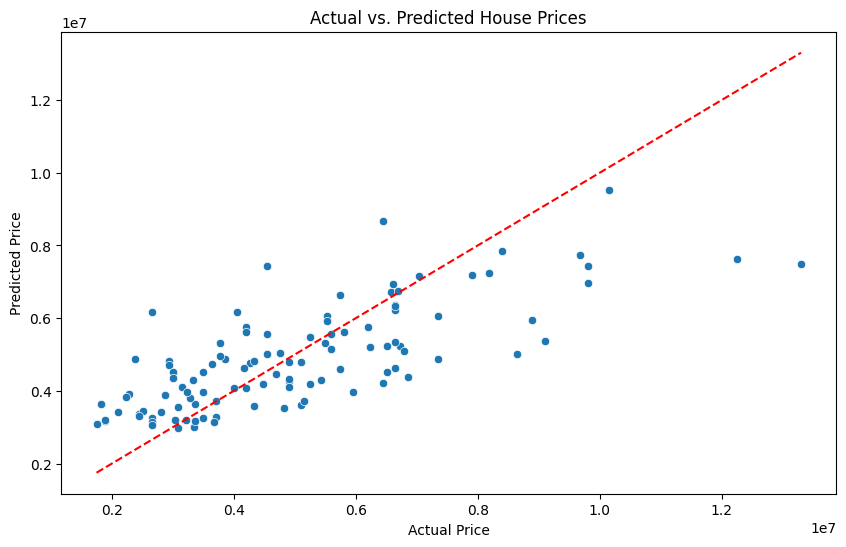

In [ ]:
# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.show()
